# Plot Original Scaling From Sampling Checkpoints

This notebook reads `NCC_original_sampling_r` checkpoints from `data/`, aggregates scaling data, and plots `expected_r_min` and `sampled_r_min` versus `N`, `T`, and `\epsilon`.

For 1-st order PF: 

Ising Gate count = $r_{min}(2*N*\kappa + \mathrm{truncation~order}+1)= r_{min}(2*N+ 4)$.

Heisenberg Gate count = $r_{min}(4*N*\kappa + 4)= r_{min}(4*N+ 4)$

In [10]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 16})
plt.rcParams['text.usetex'] = True

SAVE_PDF = 1
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data')
CHANNEL = False
RESULT_PREFIX = 'NCC_channel_original_sampling_r' if CHANNEL else 'NCC_original_sampling_r'
RESULT_LABEL = 'channel original' if CHANNEL else 'original'
BASELINE = {'N': 8, 'T': 2.0, 'epsilon': 0.001, 'trials': 1000, 'repeats': 10}
EPSILON_TARGETS = [0.1, 0.04, 0.02, 0.01, 0.005, 0.0025, 0.001] #, 0.000625]
TARGETS = {
    'N': list(range(4, 11)),
    'T': [0.2, 0.4, 0.6, 0.8, 1.0, 2.0], # , 4.0, 8.0],
    'inv_epsilon': [float(1.0 / eps) for eps in EPSILON_TARGETS],
}


THEORY_EXPONENTS = {'N': 2 / 3, 'T': 4 / 3, 'inv_epsilon': 1 / 3}

NAME_RE = re.compile(
    rf'^{RESULT_PREFIX}_N(?P<N>[^_]+)_T(?P<T>[^_]+)_eps(?P<epsilon>[^_]+)_trials(?P<trials>\d+)_repeats(?P<repeats>\d+)(?:_(?P<tag>.+))?$'
)


def parse_checkpoint(path):
    match = NAME_RE.match(path.stem)
    if match is None:
        return None
    meta = match.groupdict()
    payload = json.loads(path.read_text())
    sampled = np.array(payload['sampled_r_mins'], dtype=float)
    expected = np.array(payload['expected_r_mins'], dtype=float)
    if sampled.size <= 1:
        sampled_low = sampled_high = float(sampled.mean()) if sampled.size else float('nan')
    else:
        sampled_std = float(np.std(sampled, ddof=1))
        half_width = 1.96 * sampled_std / math.sqrt(sampled.size)
        sampled_low = float(sampled.mean() - half_width)
        sampled_high = float(sampled.mean() + half_width)
    return {
        'path': path,
        'N': int(meta['N']),
        'T': float(meta['T']),
        'epsilon': float(meta['epsilon']),
        'inv_epsilon': float(1.0 / float(meta['epsilon'])),
        'trials': int(meta['trials']),
        'repeats': int(meta['repeats']),
        'sampled_mean': float(sampled.mean()),
        'sampled_low': sampled_low,
        'sampled_high': sampled_high,
        'expected_mean': float(expected.mean()),
        'sampled_values': sampled,
        'expected_values': expected,
        'params': payload['params'],
    }


def load_records(data_dir=DATA_DIR):
    records = []
    for path in sorted(data_dir.glob(f'{RESULT_PREFIX}_*.json')):
        record = parse_checkpoint(path)
        if record is None:
            continue
        records.append(record)
    if not records:
        raise FileNotFoundError(f'No {RESULT_LABEL} sampling checkpoints found in {data_dir}')
    return records


def build_axis_series(records, axis, baseline=BASELINE, targets=TARGETS):
    filtered = []
    for record in records:
        if record['trials'] != baseline['trials'] or record['repeats'] != baseline['repeats']:
            continue
        if axis != 'N' and record['N'] != baseline['N']:
            continue
        if axis != 'T' and not math.isclose(record['T'], baseline['T'], rel_tol=0.0, abs_tol=1e-12):
            continue
        if axis != 'inv_epsilon' and not math.isclose(record['epsilon'], baseline['epsilon'], rel_tol=0.0, abs_tol=1e-12):
            continue
        filtered.append(record)
    ordered = []
    for target in targets[axis]:
        for record in filtered:
            if math.isclose(float(record[axis]), float(target), rel_tol=0.0, abs_tol=1e-12):
                ordered.append(record)
                break
    return ordered


def fit_power_law(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    coeffs = np.polyfit(np.log(x), np.log(y), 1)
    slope = float(coeffs[0])
    prefactor = float(math.exp(coeffs[1]))
    return slope, prefactor


def scaled_reference(x, y0, x0, exponent):
    x = np.array(x, dtype=float)
    return y0 * (x / x0) ** exponent


def format_tick_labels(values):
    labels = []
    for value in np.array(values, dtype=float):
        if math.isclose(value, round(value), abs_tol=1e-12):
            labels.append(str(int(round(value))))
        else:
            labels.append(f'{value:.2f}'.rstrip('0').rstrip('.'))
    return labels


def apply_center_limits(ax, x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    if x.size == 1:
        ax.set_xlim(float(x[0] / 1.2), float(x[0] * 1.2))
    else:
        ax.set_xlim(float(np.min(x) / 1.08), float(np.max(x) * 1.08))
    if y.size == 1:
        ax.set_ylim(float(y[0] / 1.2), float(y[0] * 1.2))
    else:
        ax.set_ylim(float(np.min(y) / 1.08), float(np.max(y) * 1.08))


def plot_missing(ax, title, xlabel):
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.text(0.5, 0.5, 'data not collected', ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_alpha(0.3)


def plot_expected_panel(ax, records, axis, xlabel, title, theory_exp, invert_x=False):
    if len(records) == 0:
        plot_missing(ax, title, xlabel)
        return None
    x = np.array([item[axis] for item in records], dtype=float)
    y = np.array([item['expected_mean'] for item in records], dtype=float)
    ax.loglog(x, y, 'o', ms=8, color='C0', label='expected $r_{\\min}$')
    slope = None
    if len(records) >= 2:
        slope, prefactor = fit_power_law(x, y)
        theory = scaled_reference(x, y[0], x[0], theory_exp)
        fit = prefactor * x**slope
        ax.loglog(x, theory, '--', lw=2.0, color='C1', label=rf'theory slope ${theory_exp:.3f}$')
        ax.loglog(x, fit, ':', lw=2.2, color='C2', label=rf'fit slope ${slope:.3f}$')
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x)))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if axis == 'inv_epsilon':
        ax.tick_params(axis='x', labelrotation=20)
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=18)
    # ax.set_ylabel('min gate count', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=True, fontsize=14)
    return slope


def plot_sampled_panel(ax, records, axis, xlabel, title, theory_exp, invert_x=False):
    if len(records) == 0:
        plot_missing(ax, title, xlabel)
        return None
    x = np.array([item[axis] for item in records], dtype=float)
    y = np.array([item['sampled_mean'] for item in records], dtype=float)
    yerr = np.vstack([
        y - np.array([item['sampled_low'] for item in records], dtype=float),
        np.array([item['sampled_high'] for item in records], dtype=float) - y,
    ])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.errorbar(x, y, yerr=yerr, fmt='o', ms=8, capsize=5, color='C0', label='sampled $r_{\\min}$')
    slope = None
    if len(records) >= 2:
        slope, prefactor = fit_power_law(x, y)
        theory = scaled_reference(x, y[0], x[0], theory_exp)
        fit = prefactor * x**slope
        ax.loglog(x, theory, '--', lw=2.0, color='C1', label=rf'theory slope ${theory_exp:.3f}$')
        ax.loglog(x, fit, ':', lw=2.2, color='C2', label=rf'fit slope ${slope:.3f}$')
    apply_center_limits(ax, x, y)
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x)))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if axis == 'inv_epsilon':
        ax.tick_params(axis='x', labelrotation=20)
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=18)
    # ax.set_ylabel('min gate count', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=True, fontsize=14)
    return slope


records = load_records()
series_by_axis = {
    'N': build_axis_series(records, 'N'),
    'T': build_axis_series(records, 'T'),
    'inv_epsilon': build_axis_series(records, 'inv_epsilon'),
}

print('baseline:', BASELINE)
for axis, series in series_by_axis.items():
    print(axis, [(item['N'], item['T'], item['epsilon'], item['sampled_mean'], item['expected_mean']) for item in series])


baseline: {'N': 8, 'T': 2.0, 'epsilon': 0.001, 'trials': 1000, 'repeats': 10}
N [(4, 2.0, 0.001, 379.0, 119.0), (5, 2.0, 0.001, 385.0, 90.0), (6, 2.0, 0.001, 523.1, 128.0), (7, 2.0, 0.001, 535.9, 111.0), (8, 2.0, 0.001, 673.7, 138.0)]
T [(8, 0.2, 0.001, 33.4, 9.0), (8, 0.4, 0.001, 84.5, 19.0), (8, 0.6, 0.001, 140.1, 30.0), (8, 0.8, 0.001, 207.2, 43.0), (8, 1.0, 0.001, 280.3, 57.0), (8, 2.0, 0.001, 673.7, 138.0)]
inv_epsilon [(8, 2.0, 0.1, 44.9, 31.0), (8, 2.0, 0.04, 67.3, 41.0), (8, 2.0, 0.02, 98.9, 52.0), (8, 2.0, 0.01, 149.3, 65.0), (8, 2.0, 0.005, 234.8, 81.0), (8, 2.0, 0.0025, 371.2, 102.0), (8, 2.0, 0.001, 673.7, 138.0)]


{'N': 0.26367877967948167,
 'T': 1.1861653196601385,
 'inv_epsilon': 0.32508718567651246}

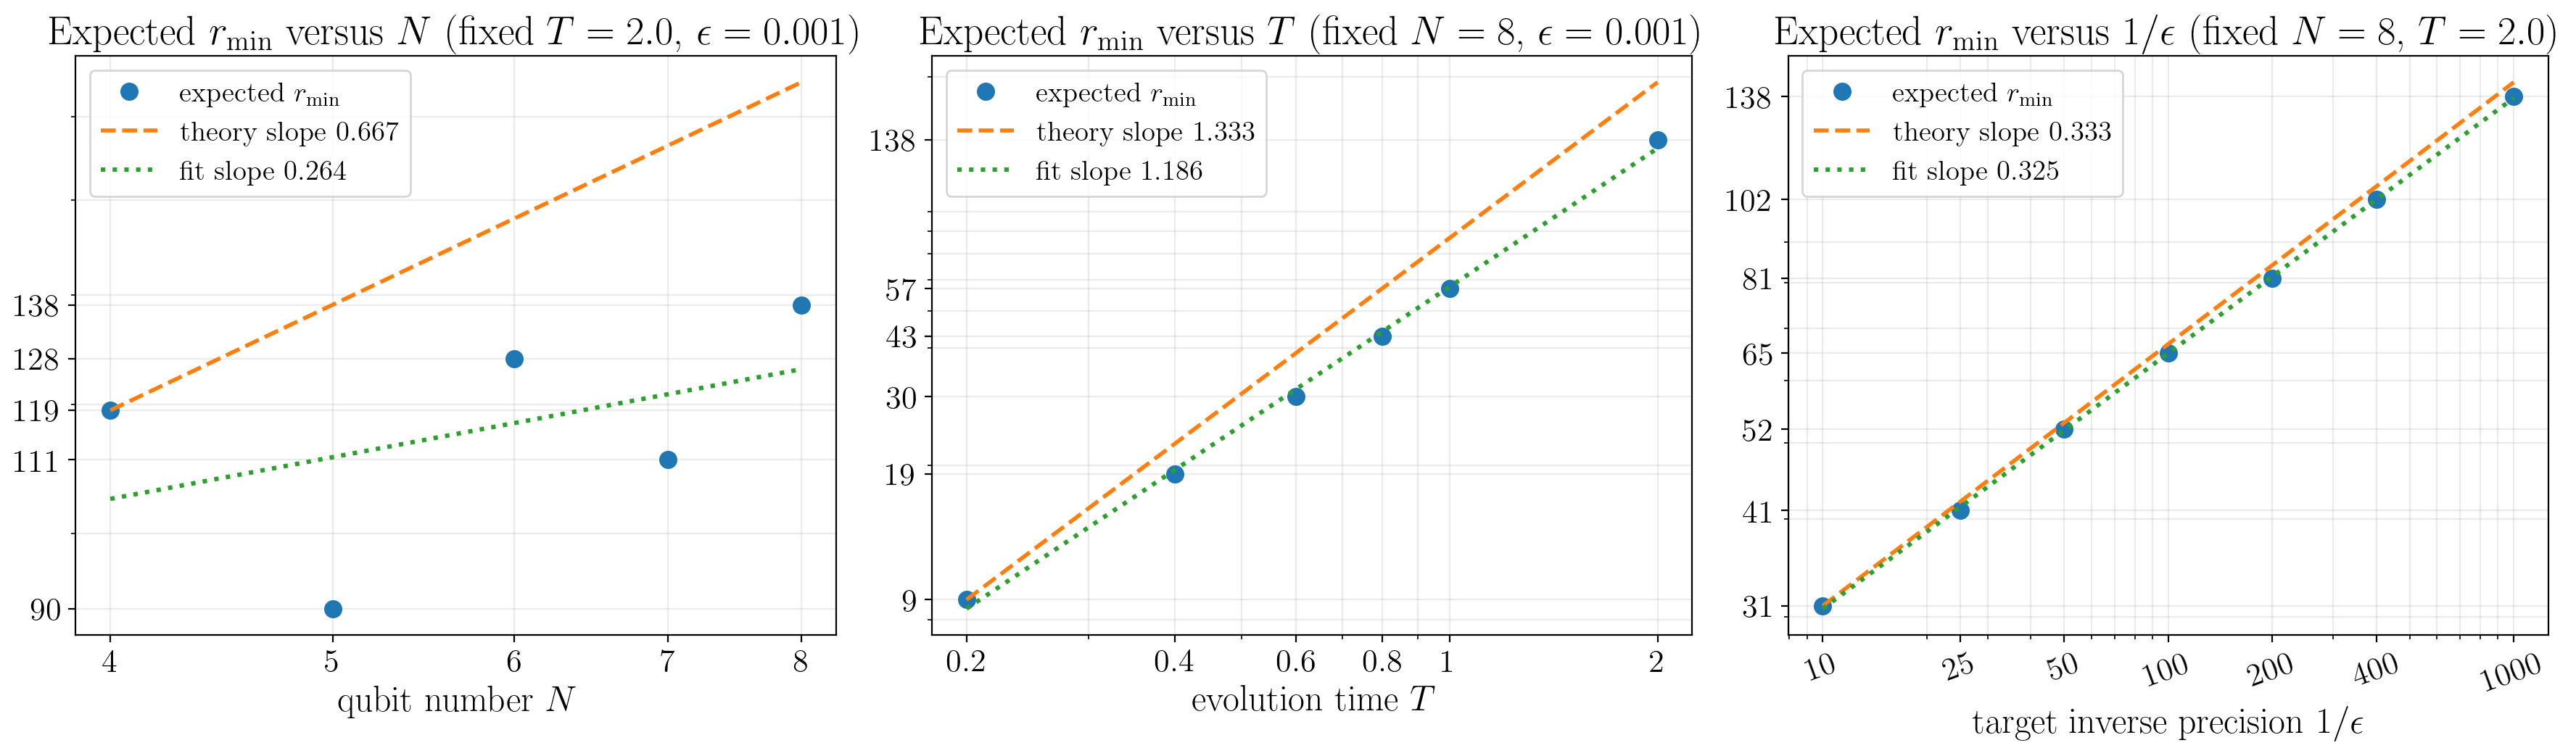

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
slopes_expected = {}
slopes_expected['N'] = plot_expected_panel(
    axes[0],
    series_by_axis['N'],
    'N',
    r'qubit number $N$',
    rf'Expected $r_{{\min}}$ versus $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['N'],
)
slopes_expected['T'] = plot_expected_panel(
    axes[1],
    series_by_axis['T'],
    'T',
    r'evolution time $T$',
    rf'Expected $r_{{\min}}$ versus $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['T'],
)
slopes_expected['inv_epsilon'] = plot_expected_panel(
    axes[2],
    series_by_axis['inv_epsilon'],
    'inv_epsilon',
    r'target inverse precision $1/\epsilon$',
    rf'Expected $r_{{\min}}$ versus $1/\epsilon$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
    THEORY_EXPONENTS['inv_epsilon'],
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / 'plot_original_expected_scaling.pdf', bbox_inches='tight')
slopes_expected


{'N': 0.8429086237554477,
 'T': 1.3058136666221403,
 'inv_epsilon': 0.5972564012248406}

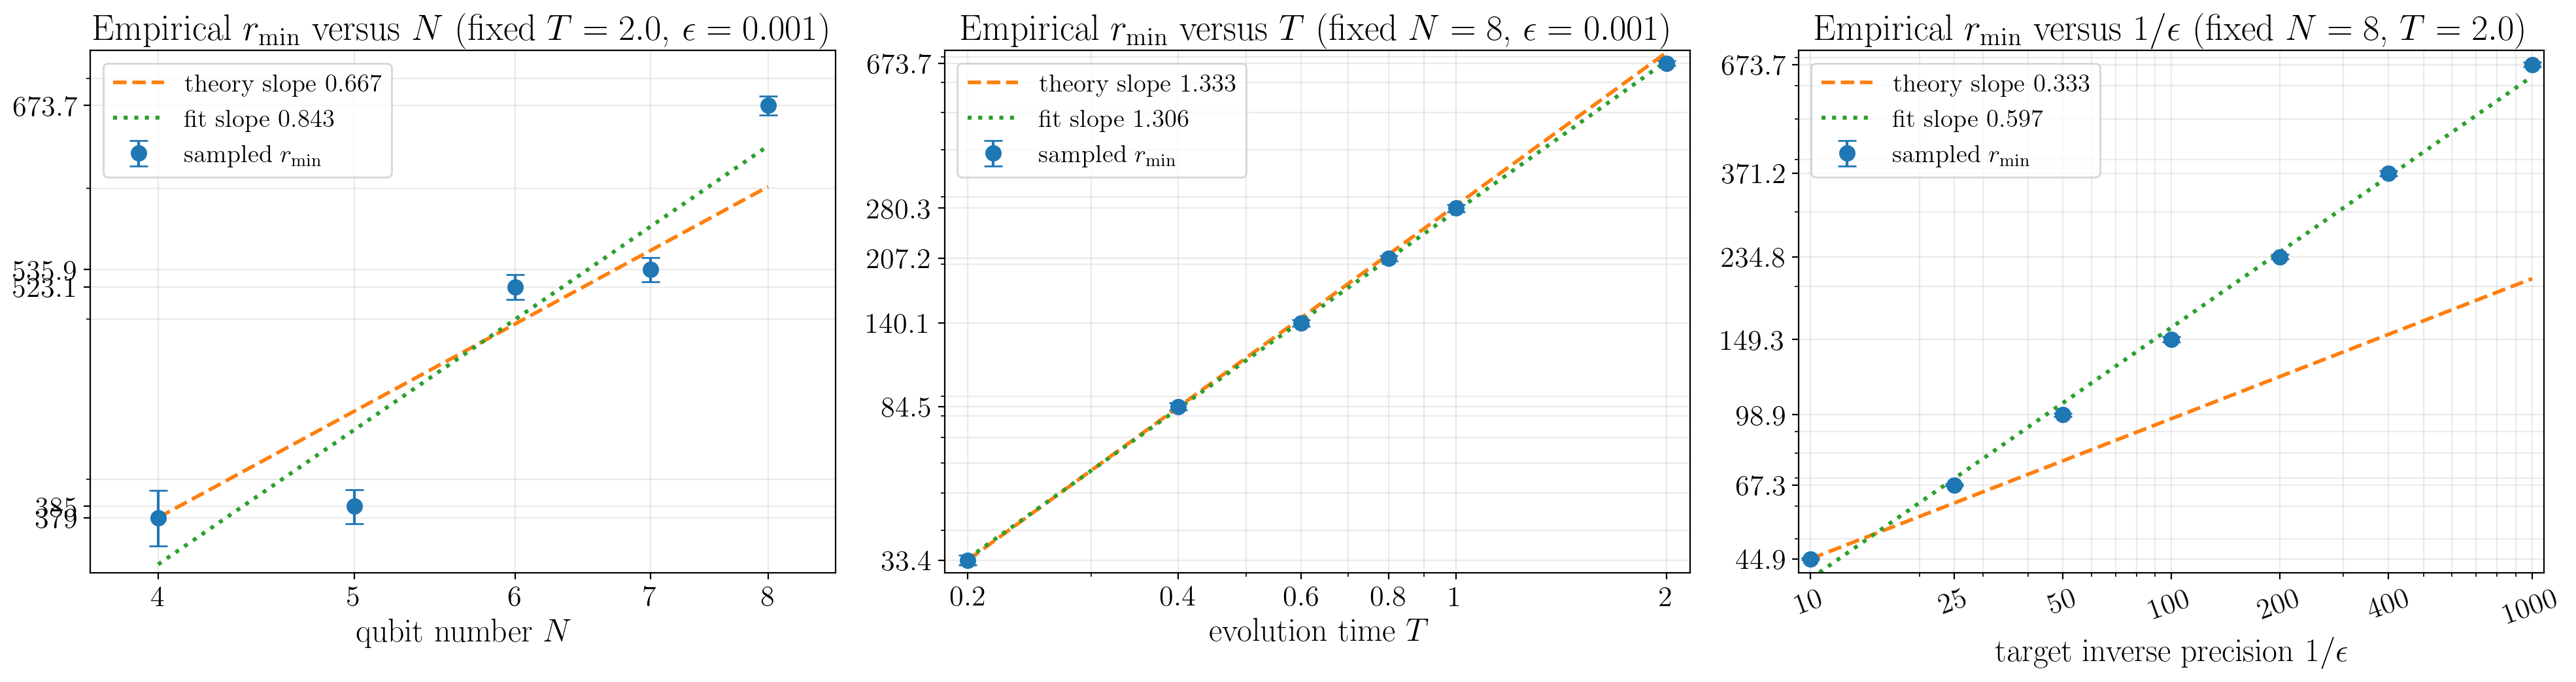

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
slopes_sampled = {}
slopes_sampled['N'] = plot_sampled_panel(
    axes[0],
    series_by_axis['N'],
    'N',
    r'qubit number $N$',
    rf'Empirical $r_{{\min}}$ versus $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['N'],
)
slopes_sampled['T'] = plot_sampled_panel(
    axes[1],
    series_by_axis['T'],
    'T',
    r'evolution time $T$',
    rf'Empirical $r_{{\min}}$ versus $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['T'],
)
slopes_sampled['inv_epsilon'] = plot_sampled_panel(
    axes[2],
    series_by_axis['inv_epsilon'],
    'inv_epsilon',
    r'target inverse precision $1/\epsilon$',
    rf'Empirical $r_{{\min}}$ versus $1/\epsilon$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
    THEORY_EXPONENTS['inv_epsilon'],
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / 'plot_original_sampled_scaling.pdf', bbox_inches='tight')
slopes_sampled
